<a href="https://colab.research.google.com/github/vivekkumarbehera/Machine_learning_Pratical_Implement/blob/main/Weather_Predict_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
global_temp=pd.read_csv("/content/GlobalTemperatures.csv")
print(global_temp.shape)
print(global_temp.columns)
print(global_temp.info())
print(global_temp.isnull().sum())



(3192, 9)
Index(['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty',
       'LandMaxTemperature', 'LandMaxTemperatureUncertainty',
       'LandMinTemperature', 'LandMinTemperatureUncertainty',
       'LandAndOceanAverageTemperature',
       'LandAndOceanAverageTemperatureUncertainty'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   dt                                         3192 non-null   object 
 1   LandAverageTemperature                     3180 non-null   float64
 2   LandAverageTemperatureUncertainty          3180 non-null   float64
 3   LandMaxTemperature                         1992 non-null   float64
 4   LandMaxTemperatureUncertainty              1992 non-null   float64
 5   LandMinTemperature                         1992 non-null   

In [3]:
#Data Preparation
def wrangle(df):
    df = df.copy()
    df = df.drop(columns=["LandAverageTemperatureUncertainty", "LandMaxTemperatureUncertainty",
                          "LandMinTemperatureUncertainty", "LandAndOceanAverageTemperatureUncertainty"], axis=1)

In [5]:
# The original code in cell Ws6nNXly-l1O had several issues:
# 1. A `SyntaxError` because of a `return df` statement placed outside a function,
#    which caused Python to misinterpret subsequent lines.
# 2. It attempted to modify a DataFrame `df` directly in the global scope without `df` being defined,
#    as the `wrangle` function (which would provide `df`) was incomplete and called later.
# 3. The `wrangle` function was split across two cells, leading to an incomplete definition in the first cell
#    and global scope execution in the second.
# 4. The `converttemp` function contained a bug: it used an undefined `x` instead of the input parameter `X`,
#    and it didn't return the calculated Fahrenheit value.
# 5. It used `df.Year` (capitalized) when the column was created as `df['year']` (lowercase).

# This cell now provides the complete definition for the `wrangle` function
# and then calls it to process the `global_temp` DataFrame.
def wrangle(df):
    df = df.copy()

    # Drop uncertainty columns, as was partially defined in the previous 'wrangle' cell.
    # Note: The previous cell `t6qgMCGe-OK5` should ideally be removed or cleared after this fix,
    # as the `wrangle` function is now fully defined here.
    df = df.drop(columns=["LandAverageTemperatureUncertainty", "LandMaxTemperatureUncertainty",
                          "LandMinTemperatureUncertainty", "LandAndOceanAverageTemperatureUncertainty"], axis=1)

    # Helper function to convert Celsius to Fahrenheit
    def convert_to_fahrenheit(celsius_temp):
        # Handle NaN values to prevent errors
        if pd.isna(celsius_temp):
            return celsius_temp
        return (celsius_temp * 1.8) + 32

    # Apply temperature conversion to relevant columns
    df['LandAverageTemperature'] = df['LandAverageTemperature'].apply(convert_to_fahrenheit)
    df['LandMaxTemperature'] = df['LandMaxTemperature'].apply(convert_to_fahrenheit)
    df['LandMinTemperature'] = df['LandMinTemperature'].apply(convert_to_fahrenheit)
    df['LandAndOceanAverageTemperature'] = df['LandAndOceanAverageTemperature'].apply(convert_to_fahrenheit)

    # Process date column and create 'year' and 'month'
    df['dt'] = pd.to_datetime(df['dt'])
    df['year'] = df['dt'].dt.year
    df['month'] = df['dt'].dt.month
    df = df.drop('dt', axis=1)
    df = df.drop('month', axis=1)

    # Filter data and set index, correcting column name from 'Year' to 'year'
    df = df[df.year >= 1850]
    df = df.set_index(["year"])
    df = df.dropna() # Drop rows with any remaining NaN values
    return df

# Call the wrangle function with the global_temp DataFrame
global_temp = wrangle(global_temp)
print(global_temp.head())

      LandAverageTemperature  LandMaxTemperature  LandMinTemperature  \
year                                                                   
1850                 33.3482             46.8356             26.2292   
1850                 37.5278             49.9460             27.8762   
1850                 40.9172             50.6246             28.5710   
1850                 44.9906             55.2812             33.8324   
1850                 50.0072             60.1790             38.8598   

      LandAndOceanAverageTemperature  
year                                  
1850                         55.0994  
1850                         56.4584  
1850                         57.2774  
1850                         58.4006  
1850                         59.9126  


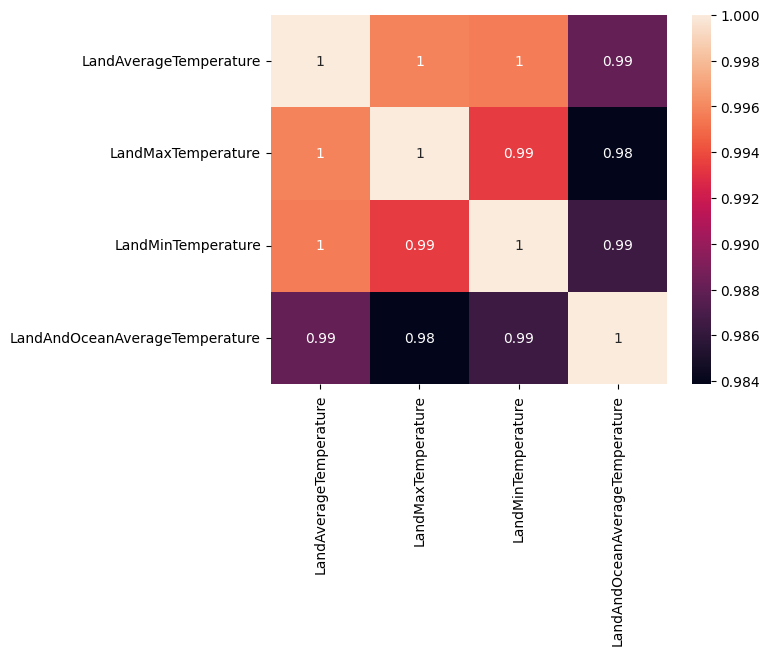

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
corrMatrix = global_temp.corr()
sns.heatmap(corrMatrix, annot=True)
plt.show()

In [8]:
target = "LandAndOceanAverageTemperature"
y = global_temp[target]
x = global_temp[["LandAverageTemperature", "LandMaxTemperature", "LandMinTemperature"]]

In [10]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)


ypred = [ytrain.mean()] * len(ytrain)
print("Baseline MAE: ", round(mean_squared_error(ytrain, ypred), 5))

Baseline MAE:  5.29052


In [12]:
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
forest = make_pipeline(
    SelectKBest(k="all"),
    StandardScaler(),
    RandomForestRegressor(
        n_estimators=100,
        max_depth=50,
        random_state=77,
        n_jobs=-1
    )
)
forest.fit(xtrain, ytrain)

Pipeline(steps=[('selectkbest', SelectKBest(k='all')),
                ('standardscaler', StandardScaler()),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=50, n_jobs=-1,
                                       random_state=77))])

In [14]:
import numpy as np

# Get predictions from the trained Random Forest model on the test set
ypred = forest.predict(xtest)

# Calculate errors using the true values from the test set (ytest)
errors = abs(ypred - ytest)

# Calculate Mean Absolute Percentage Error (MAPE)
mape = 100 * (errors / ytest)

# Calculate accuracy
accuracy = 100 - np.mean(mape)

print("Random Forest Model Accuracy: ", round(accuracy, 2), "%")

Random Forest Model Accuracy:  99.58 %
